{
    'topic': '猫',
    'poem': '## 
猫の天体\n\n目を閉じた\n砂時計がひっくり返る音がする\n午後の昏睡の底で\n尾が時間を撫でている\n\nぴんと張った背筋の\
n微かな震えは\n無重力の予感\n肉球の裏に刻まれた\nそっと一筋\n淡い月光\n\n伸びをすれば\n宇宙の具合を確かめる\n瞬きの
たび\n世界がきしり\nじわりと輪郭を\n線に変える\n\n呼べども応えず\n水のように透けた\nその存在は\nまなこを閉ざしたま
ま\nどんな夢の深みを\n蹲っているのか\n\n夜が満ちて\n部屋の隅に置かれた\n古びた羽毛\nそれは生きたままの\n飼いならざ
る時間\n月光を\n背に受けて眠る\nくびれた影',
    'ci_poem': '猫の背に 夕日あたため 昼寝する 君の微睡は 春のごとし\n\n爪とぎの 音は静けき 午後の部屋 猫の気まぐれ
春の風吹く\n\n瞳閉じ 喉を鳴らすは 子守唄 君の隣に 永遠の夢\n\nひとつ鳴き またひとつ鳴き 夜の闇 猫の声に 
星が瞬く\n\n君あれば 我が心にも 猫のごと 自由と優しさ 宿りにけり',
    'content_type': '詩'
}

{
    'topic': '猫',
    'joke': 'もちろんです！猫をテーマにしたジョークをいくつかどうぞ。\n\n1. 
**「猫がコンピューターを嫌う理由は？」**  \n   「だって、マウスをクリックしても何も起こらないからだニャ。」\n\n2. 
**「猫はなぜインターネットが嫌いなの？」**  \n   
「ダイヤルアップの時代から、接続にゃかなり時間がかかるから。」\n\n3. **「猫がギターを弾けないのはなぜ？」**  \n   
「コード（和音）を押さえても、どうしても爪が立つから。」\n\n4. **「猫がブログを書かない理由は？」**  \n   
「毎日、『寝てた』『食べた』『また寝た』しか書くことがないから。」\n\n5. **「猫が運転免許を取れないのはなぜ？」**  
\n   「『にゃん』という合図が、ウィンカーに見えないから。」\n\nどうぞ笑ってください！ニャ。',
    'ci_poem': '硝子の目 琥珀の奥に 眠る火を\n猫は知っている 月の裏側を',
    'content_type': 'ジョーク'
}

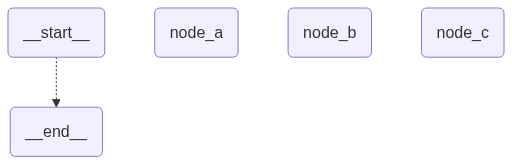

In [1]:
from typing import TypedDict,Literal,Sequence
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv(override=True)
from rich import print

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking":{
            "type":"disabled"
        }
    }
)

#1. 状態を定義
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    ci_poem:str
    content_type: str

#2. ノードを定義
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"{state['topic']}をテーマにした詩を書いてください"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"{state['topic']}をテーマにしたジョークを書いてください"]).content
    return {
        "joke": joke
    }

def node_c(state: OverAllState) -> OverAllState:
    ci_poem = model.invoke([f"{state['topic']}をテーマにした短歌を詠んでください"]).content
    return {
        "ci_poem": ci_poem
    }

def my_route(state: OverAllState) -> Sequence[Literal["node_a","node_b","node_c"]]:
    if "詩" in state["content_type"]:
        return ["node_a","node_c"]
    else:
        return ["node_b","node_c"]


#3. グラフを構築
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_node(node_c)

builder.add_conditional_edges(START,my_route)
builder.add_edge("node_b",END)
builder.add_edge("node_a",END)
builder.add_edge("node_c",END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫","content_type":"詩"})
print(poem_res)

joke_res = graph.invoke({"topic": "猫","content_type":"ジョーク"})
print(joke_res)

from IPython.display import display
display(graph)
